## Inroduction to Probabilistic Machine Learning  

Family name: Yu

Name: Belisa

Date: 9/02/2026

## The exponential distribution
Given an exponential random variable whose pdf is
$$
\text{exp\_pdf}\left(x, \lambda \right) = \frac{1}{Z(\lambda)} \exp\left(- \lambda x \right)
$$

[TODO] Derive using markdown + latex:
1. the normalization constant $ Z(\lambda)$,
2. the cdf,
3. the inverse cdf.

1. $\int_{0}^{\infty} \frac{1}{Z(\lambda)} e^{-\lambda x} dx = \left[\frac{1}{Z(\lambda)} \cdot \frac{1}{-\lambda} \cdot e^{-\lambda x} \right]_{0}^{\infty} = 0 - \frac{1}{Z(\lambda)} \cdot \frac{1}{-\lambda} = 1; \frac{1}{\lambda \cdot Z(\lambda)} = 1; Z(\lambda) = \frac{1}{\lambda}$

2. $\int_{0}^{\infty} dz \cdot pdf(z)=\int_{0}^{\infty} \frac{1}{Z(\lambda)} \cdot e^{-\lambda x} dx=\int_{0}^{x} \lambda \cdot e^{-\lambda x} dx=\lambda \cdot \int_{0}^{x} e^{-\lambda x} dx = \lambda \cdot \left[\frac{1}{-\lambda} e^{-\lambda x} \right]_{0}^{x} = \lambda \cdot [\frac{1}{-\lambda} \cdot e^{-\lambda x} - \frac{1}{-\lambda}]=-e^{-\lambda x} +1= 1 - e^{-\lambda x}$

3. $1-e^{-\lambda x} = P; e^{-\lambda x} = 1 - P; -\lambda x = \ln(1-P); x = \frac{-1}{\lambda} \cdot \ln(1-P)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tools import exp_distribution, probabilistic_fit

### Method of the inverse

In [2]:
# [TODO] Generate an iid sample of the exponential distribution using the method of the inverse 

rng = np.random.default_rng(123)
lam_true = 1.5
N = 10000

u = rng.uniform(0.0,1.0, size=N)
X = exp_distribution.exp_inv(u, lam_true)

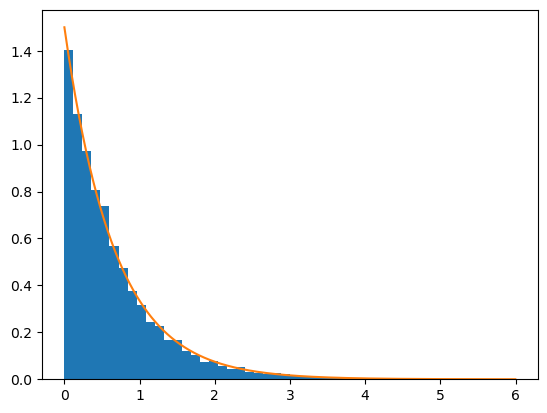

In [3]:
# [TODO] Plot the histogram of the sample and compare with pdf
x_vals = np.linspace(0, max(X), 1000) # x-values for the curve
pdf = exp_distribution.exp_pdf(x_vals, lam_true) #pdf distribution

n_bins = min(np.sqrt(N), 50)
plt.hist(X,bins=n_bins, density=True);
plt.plot(x_vals, pdf);

## Maximum Likelihood estimate of $\lambda$

[TODO] Derive using markdown + latex:
1. The expression of the likelihood function for the iid sample $ \mathcal{D} = \left\{X_n \right\}_{n=1}^N$
2. The value of $\lambda$ that maximizes the likelihood
3. The expression of the posterior assuming the prior for lambda 

#### Solution:
The likelihood is
$$
\mathcal{L}(\lambda; \mathcal{D}) = P\left( \mathcal{D}  \vert \lambda \right) 
= P\left( \left\{X_n \right\}_{n=1}^N  \vert \lambda \right) 
= \prod_{n=1}^N \mathrm{exp\_pdf}\left( X_n ; \lambda \right) 
= \prod_{n=1}^N \left(\lambda \exp\left( - \lambda X_n \right)\right) 
= \lambda^N \exp\left(-\lambda \sum_{n=1}^N X_n\right).
$$

The corresponding log-likelihood  is
$$
\mathcal{LL}(\lambda; \mathcal{D})
= \log \mathcal{L}(\lambda; \mathcal{D})
= N \log \lambda - \lambda \sum_{n=1}^N X_n.
$$

Taking the derivative of this likelihood with respect to $\lambda$,
$$
\frac{d\mathcal{LL}(\lambda; \mathcal{D})}{d\lambda}
= \frac{N}{\lambda} - \sum_{n=1}^N X_n.
$$

Setting the derivative equal to zero gives
$$
\frac{N}{\lambda_{ML}^*} - \sum_{n=1}^N X_n = 0 
\quad \Longrightarrow \quad
\frac{N}{\lambda_{ML}^*} = \sum_{n=1}^N X_n.
$$
Hence the maximum likelihood estimator is
$$
\lambda_{ML}^* = \frac{N}{\sum_{n=1}^N X_n}
= \frac{1}{\hat{\mu}_X},
$$
where
$$
\hat{\mu}_X = \frac{1}{N}\sum_{n=1}^N X_n.
$$

The second derivative,
$$
\frac{d^2\mathcal{LL}(\lambda; \mathcal{D})}{d\lambda^2}
= -\frac{N}{\lambda^2} < 0,
$$
is negative, which confirms that this critical point (zero derivative) is a maximum.


#### *Maximum likelihood estimate for exponential function*
Density function of exponencial = $f(x;\lambda) = \lambda \cdot e^{-\lambda x}$ <br>
The likelihood is: $L(\lambda) = \prod_{i=1}^{N}f(x_{i};\lambda) = \prod_{i=1}^{N}\lambda \cdot e^{-\lambda x_{i}}$ <br>
The corresponding log-likelihood is: $log L(\lambda) = N \cdot log(\lambda) - \lambda \sum_{i=1}^{N} x_{i}$ <br>
Deriving and equaling to zero: $\frac{dl}{d\lambda} = \frac{N}{\lambda} - \sum_{i=1}^{N} x_{i} = 0$ <br>
Solving $\lambda$ : $\frac{N}{\lambda} - \sum_{i=1}^{N} x_{i} = 0; \frac{N}{\lambda} = \sum_{i=1}{N} x_{i}; \lambda = \frac{N}{\sum_{i=1}^{N} x_{i}}$

### Numerical maximization of the likelikood 

We shall now use a numerical method to maximize the likelihood and compare with the closed-form solution.

In [4]:
# [TODO]
lam_mle_analytic =   1/ np.mean(X)# Closed-form formula derived in previous cell
lam_mle_numerical =  probabilistic_fit.maximum_likelihood_fit(exp_distribution.exp_pdf, X)# Numerical estimate from optimization

print(lam_mle_numerical, lam_mle_analytic)

1.537014441060021 1.5370144518224336


## MAP estimate of $\lambda$
Assume the conjugate prior
$$
\lambda \sim \mathrm{Gamma}(\alpha,\beta),
$$
with density
$$
p(\lambda) = \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta \lambda}.
$$

[TODO] Derive using markdown + latex:
1. the expression of the posterior assuming the Gamma prior for $\lambda$, 
2. the value of $\lambda$ that maximizes the posterior.  

1. Likelihood: $L(\lambda | X) = \prod_{i=1}^{N} \lambda \cdot e^{-\lambda x_{i}} = \lambda^{N} \cdot e^{-\lambda \cdot \sum_{i=1}^{N} x_{i}}$ <br>
Density function (prior): $p(\lambda) = \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta \lambda}.$ <br>
Posterior ∝ likelihood x prior ==> $p(\lambda|X) ∝ p(X|\lambda)\cdot p(\lambda) = \lambda^{N} \cdot e^{-\lambda \cdot \sum_{i=1}^{N} x_{i}} \cdot \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta \lambda}$ (as it is proportional and $\frac{\beta^\alpha}{\Gamma(\alpha)}$ does not depend on $\lambda$ we can submit it) <br>
So posterior will be proportional to: $p(\lambda|X) ∝ p(X|\lambda)\cdot p(\lambda) = \lambda^{N} \cdot e^{-\lambda \cdot \sum_{i=1}^{N} x_{i}} \cdot \lambda^{\alpha-1} e^{-\beta \lambda} = \lambda^{N + \alpha-1} \cdot e^{-\lambda(\beta+\sum x_{i})}$ 

2. To maximize we need to find the corresponding log-likelihood, then derivate respect to lambda and equaling to zero
Log-likelihood: $l(\lambda) = log p(\lambda|X) = (N+\alpha-1)log \lambda - \lambda(\beta + \sum x_{i})$ <br>
Derivating respect to lambda ==> $\frac{dl}{d\lambda} = \frac{(N+\alpha-1)}{\lambda} - (\beta + \sum x_{i})$ <br>
Setting the derivative equals to zero: $\frac{(N+\alpha_-1)}{\lambda_{MAP^{*}}} - (\beta + \sum x_{i}) = 0; \frac{(N+\alpha-)}{\lambda_{MAP^{*}}} = \beta + \sum x_{i}; \lambda_{MAP^{*}} = \frac{(N+\alpha-1)}{\beta+ \sum x_{i}} $

### Numerical maximization of the posterior 

We shall now use a numerical method to maximize the posterior.

In [5]:
# [TODO]
alpha = 4.0
beta = 0.1
def gamma_prior(lam):
    return (beta**alpha)/np.math.gamma(alpha) * lam**(alpha-1) * np.exp(-beta*lam)
lam_map_analytic = (N+alpha-1)/(beta+sum(X))# Closed-form formula derived in previous cell
lam_map_numerical =  probabilistic_fit.maximum_posterior_fit(exp_distribution.exp_pdf,gamma_prior, X)# Numerical estimate from optimization


print(lam_map_analytic, lam_map_numerical)

1.5374519252996937 1.5374519198237457


### Questions
[TODO] Answer these question using markdown + latex:
1. What are the values of the mean, the standandard deviation, and the mode of the prior of $\lambda$?
2. How different are the ML and MAP estimates of $\lambda$?
    * When the sample size \(N = 100\) are they very different?
    * When the sample size \(N = 1000\) are they very different?
3. What do you conclude from the answers to the previous questions?


**1.** 
- Mean of prior ==> $E[\lambda] = \int_{0}^{\infty} \lambda \cdot p(\lambda) d\lambda = \int_{0}^{\infty} \lambda \cdot \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta \lambda} d\lambda = \frac{\beta^{\alpha}}{\gamma(\alpha)} \int_{0}^{\infty} \lambda^{\alpha} e^{-\beta\lambda} d\lambda --> t = \beta\lambda --> \frac{\beta^{\alpha}}{\gamma(\alpha)} \int_{0}^{\infty} (\frac{t}{\beta})^{\alpha} e^{-t\frac{dt}{\beta}} = \frac{\beta^{\alpha}}{\gamma(\alpha)} \cdot \frac{1}{\beta^{\alpha+1}} \int_{0}^{\infty} t^{\alpha}e^{-t}dt --> gamma function (\gamma(p) = \int_{0}^{\infty} x^{p-1}e^{-x}) --> \frac{\beta^{\alpha}}{\gamma(\alpha)}\cdot \frac{1}{\beta^{\alpha+1}} \int_{0}^{\infty} t^{(\alpha-1)+1}e^{-t} = \frac{\beta^{\alpha}}{\gamma(\alpha)}\cdot \frac{1}{\beta^{\alpha+1}} \cdot \gamma(\alpha+1) = \frac{\beta^{\alpha}\alpha\gamma(\alpha)}{\gamma(\alpha)\beta^{\alpha}\beta} = \frac{\alpha}{\beta} = \frac{4}{0.1} = 40$ <br>
- Standandard deviation -> $E[\lambda^{2}]-(E[\lambda])^{2} = E[(\frac{\alpha}{\beta})^{2}] - (E[\frac{\alpha}{\beta}])^{2}$ <br>
    - As we already have $(E[\frac{\alpha}{\beta}])^{2}$, we only need to calculate $E[(\frac{\alpha}{\beta})^{2}]$ the same way as above
    - $E[(\frac{\alpha}{\beta})^{2}] = \int_{0}^{\infty} \lambda^{2} p(\lambda) d\lambda ==> E[(\frac{\alpha}{\beta})^{2}] = \frac{\beta^{\alpha}}{\gamma(\alpha)} \int_{0}^{\infty} \lambda^{\alpha+1}e^{-\beta\lambda} d\lambda $
    - Change of variable $t = \beta\lambda$ --> $E[(\frac{\alpha}{\beta})^{2}] = \frac{\beta^{\alpha}}{\gamma(\alpha)}\int_{0}^{\infty} (\frac{t}{\beta})^{\alpha+1} e^{-t} \frac{dt}{\beta} = \frac{\beta^{\alpha}}{\gamma(\alpha)}\cdot\frac{1}{\beta^{\alpha+2}}\int_{0}^{\infty} t^{\alpha+1}e^{-t}dt$
    - The function gamma is defined as: $\gamma{p} = \int_{0}^{\infty} x^{p-1}e^{-x}$, so aplying it to our function, we get ==> $\frac{\beta^{\alpha}}{\gamma(\alpha)}\cdot\frac{1}{\beta^{\alpha+2}}\cdot\gamma(\alpha+2) = \frac{\beta^{\alpha}}{\gamma(\alpha)} \cdot \frac{\gamma(\alpha+2)}{\beta^{\alpha+2}}$
    - Using the gamma properties and exponent properties we get: $E[(\frac{\alpha}{\beta})^{2}] = \frac{\beta^{\alpha}\cdot(\alpha+1)\alpha\gamma(\alpha)}{\gamma(\alpha)\beta^{\alpha}\beta^{2}} = \frac{(\alpha+1)\alpha}{\beta^{2}} = \frac{(4.0+1)4.0}{0.1^{2}} = 1640$ <br>
- Mode -> is the lambda that maximices pdf -> $\lambda_{mode} = argmax p(\lambda) --> argmax p(\lambda)$ = argmax log $p(\lambda)$
    - log $p(\lambda)$ = log $\frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta \lambda}$ = $\alpha log \beta - log \gamma(\alpha) + (\alpha-1) log \lambda -\beta\lambda$
    - We derive respect log $p(\lambda)$ ==> $\frac{dlogp(\lambda)}{d\lambda} = \frac{\alpha-1}{\lambda}-\beta$
    - Equal to zero ==> $\frac{\alpha-1}{\lambda}-\beta = 0;\frac{\alpha-1}{\lambda} = \beta; \lambda = \frac{\alpha-1}{\beta}$
    - Mode is: $\lambda = \frac{\alpha-1}{\beta}; \lambda = \frac{4.0-1}{0.1} = 30$

**2.**
- ML = $\lambda = \frac{N}{\sum_{i=1}^{N} x_{i}}$
- MAP = $\frac{(N+\alpha-1)}{\beta+ \sum x_{i}}$
- For N = 100: 
    - ML ==> $\lambda = \frac{100}{\sum_{i=1}^{N} x_{i}}$
    - MAP ==> $\frac{N+\alpha-1}{\beta+\sum x_{i}} = \frac{(100 + \alpha-1)}{\beta + \sum x_{i}}$ <br>
    As MAP is data + prior and ML is only data, when N is really big the prior data doesn't affect much, so when N = 100, the value depends on $\beta$ although their values are going to be close. But, when N=1000, as it is a big sample, prior is not going to affect the answer, so ML ~ MAP

**3.** 
Map is data+prior and ML is only data, so when the samples are really big, MAP ~ ML


### Summary and conclusions 
[TODO] Summary and conclusions of what I have learned using markdown + latex:
1. [TODO: as many as necessary]
2. Fit a model pdf to an iid sample using the maximum likelihood method.
3. [TODO: as many as necessary]
4.
...


1. How to write in latex
2. PDF, CDF and $CDF^{-1}$ functions
3. The Gamma function
4. Difference between MAP and ML